In [2]:
import sqlite3
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score

# Try to find the correct database file
import os
# db_files = [f for f in os.listdir('.') if f.endswith('.db') or f.endswith('.sqlite') or 'text' in f]
db_path = '/projects/p32143/RL_human_decision/statistic/text_2026-09-23.db'
# if not os.path.exists(db_path) and db_files:
#     db_path = db_files[0] # Fallback to the first db file found

methods = {
    'HD-RL': 'rl_text_guess',
    'LLM_decision': 'llm_decision_guess',
    'DPO': 'llm_preference_guess',
    'VR-GRPO': 'rlvr_guess'
}

try:
    conn = sqlite3.connect(db_path)
    results = []
    
    for method, table in methods.items():
        # Query the data
        df = pd.read_sql_query(f"SELECT label_truth, guess, correct FROM {table} WHERE guess IS NOT NULL AND guess != ''", conn)
        
        # Standardize strings to lowercase just in case
        df['label_truth'] = df['label_truth'].str.lower()
        df['guess'] = df['guess'].str.lower()
        
        # Accuracies
        overall_acc = df['correct'].mean()
        acc_human = df[df['label_truth'] == 'human']['correct'].mean()
        acc_ai = df[df['label_truth'] == 'ai']['correct'].mean()
        
        # P/R/F1 treating 'ai' as the positive class
        y_true = (df['label_truth'] == 'ai').astype(int)
        y_pred = (df['guess'] == 'ai').astype(int)
        
        precision = precision_score(y_true, y_pred, zero_division=0)
        recall = recall_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        
        results.append({
            'Method': method,
            'Overall Accuracy': f"{overall_acc:.4f}",
            'Acc (Human Text)': f"{acc_human:.4f}",
            'Acc (AI Text)': f"{acc_ai:.4f}",
            'Precision (AI)': f"{precision:.4f}",
            'Recall (AI)': f"{recall:.4f}",
            'F1 Score (AI)': f"{f1:.4f}",
            'Count': len(df)
        })

    results_df = pd.DataFrame(results)
    print(results_df.to_markdown(index=False))
except Exception as e:
    print("Error:", e)
    print("Files in dir:", os.listdir('.'))

| Method       |   Overall Accuracy |   Acc (Human Text) |   Acc (AI Text) |   Precision (AI) |   Recall (AI) |   F1 Score (AI) |   Count |
|:-------------|-------------------:|-------------------:|----------------:|-----------------:|--------------:|----------------:|--------:|
| HD-RL        |             0.6559 |             0.6801 |          0.63   |           0.6473 |        0.63   |          0.6385 |    2488 |
| LLM_decision |             0.5528 |             0.6122 |          0.4909 |           0.5486 |        0.4909 |          0.5182 |    1572 |
| DPO          |             0.5187 |             0.5775 |          0.4568 |           0.5065 |        0.4568 |          0.4803 |    2113 |
| VR-GRPO      |             0.5343 |             0.5904 |          0.4731 |           0.5142 |        0.4731 |          0.4928 |    1282 |


Plot saved as smoothed_loss_recreation.png


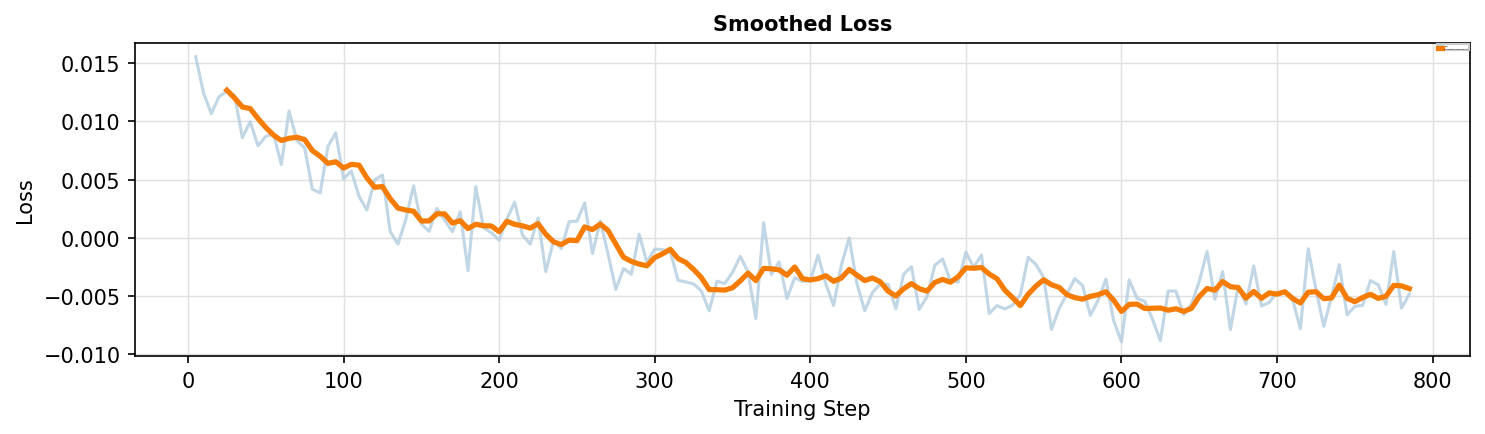

In [9]:
import matplotlib.pyplot as plt
import pandas as pd

# Load the provided data
data = {
  "step": [
    5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100, 105, 110, 115, 120, 125, 130, 135, 140, 145, 150, 155, 160, 165, 170, 175, 180, 185, 190, 195, 200, 205, 210, 215, 220, 225, 230, 235, 240, 245, 250, 255, 260, 265, 270, 275, 280, 285, 290, 295, 300, 305, 310, 315, 320, 325, 330, 335, 340, 345, 350, 355, 360, 365, 370, 375, 380, 385, 390, 395, 400, 405, 410, 415, 420, 425, 430, 435, 440, 445, 450, 455, 460, 465, 470, 475, 480, 485, 490, 495, 500, 505, 510, 515, 520, 525, 530, 535, 540, 545, 550, 555, 560, 565, 570, 575, 580, 585, 590, 595, 600, 605, 610, 615, 620, 625, 630, 635, 640, 645, 650, 655, 660, 665, 670, 675, 680, 685, 690, 695, 700, 705, 710, 715, 720, 725, 730, 735, 740, 745, 750, 755, 760, 765, 770, 775, 780, 785
  ],
  "loss": [
    0.015543, 0.012447, 0.010665, 0.012121, 0.012572, 0.012206, 0.008595, 0.009967, 0.007902, 0.008702, 0.008924, 0.006290, 0.010894, 0.008338, 0.007727, 0.004168, 0.003862, 0.007863, 0.009011, 0.005054, 0.005726, 0.003543, 0.002379, 0.004980, 0.005383, 0.000528, -0.000530, 0.001563, 0.004463, 0.001189, 0.000558, 0.002527, 0.001520, 0.000522, 0.002231, -0.002831, 0.004384, 0.000865, 0.000438, -0.000206, 0.001609, 0.003064, 0.000237, -0.000543, 0.001692, -0.002906, -0.000234, -0.000921, 0.001388, 0.001426, 0.002997, -0.001358, 0.001456, -0.001381, -0.004437, -0.002643, -0.003125, 0.000310, -0.002098, -0.000961, -0.001020, -0.001167, -0.003651, -0.003790, -0.003955, -0.004561, -0.006266, -0.003724, -0.003931, -0.002967, -0.001593, -0.002931, -0.006936, 0.001293, -0.003129, -0.002063, -0.005201, -0.003419, -0.003746, -0.003661, -0.001502, -0.003958, -0.005814, -0.002318, -0.000015, -0.003957, -0.006262, -0.004697, -0.003969, -0.003994, -0.006087, -0.003127, -0.002480, -0.006141, -0.005066, -0.002366, -0.001818, -0.003668, -0.003817, -0.001238, -0.002534, -0.001480, -0.006500, -0.005821, -0.006106, -0.005782, -0.004881, -0.001678, -0.002283, -0.003412, -0.007866, -0.006058, -0.004811, -0.003506, -0.004104, -0.006661, -0.005347, -0.003548, -0.007132, -0.008931, -0.003627, -0.005207, -0.005459, -0.007018, -0.008827, -0.004573, -0.004576, -0.006604, -0.005699, -0.003737, -0.001171, -0.005266, -0.002908, -0.007884, -0.004144, -0.005677, -0.002419, -0.005859, -0.005548, -0.004681, -0.004633, -0.005321, -0.007809, -0.000942, -0.004434, -0.007599, -0.005047, -0.002298, -0.006622, -0.005881, -0.005803, -0.003671, -0.004032, -0.005718, -0.001180, -0.006040, -0.004839
  ]
}

df = pd.DataFrame(data)

# Calculate the rolling mean with a window of 5
df['smoothed_loss'] = df['loss'].rolling(window=5).mean()

# Set up the plot with dimensions similar to the reference image
fig, ax = plt.subplots(figsize=(10, 3), dpi=150)

# Plot the raw data (light blue, slightly transparent)
ax.plot(df['step'], df['loss'], label='Raw', color='#B3CDE0', linewidth=1.5, alpha=0.8)

# Plot the smoothed data (orange, thicker line)
ax.plot(df['step'], df['smoothed_loss'], label='Smoothed (window=5)', color='#F57C00', linewidth=2.5)

# Formatting titles and labels
ax.set_title('Smoothed Loss', fontweight='bold', fontsize=10)
ax.set_xlabel('Training Step', fontsize=10)
ax.set_ylabel('Loss', fontsize=10)

ax.tick_params(axis='y', labelsize=10)
ax.tick_params(axis='x', labelsize=10)

# Grid styling
ax.grid(True, color='#E0E0E0', linestyle='-', linewidth=0.7)

# Legend styling
ax.legend(loc='upper right', fontsize=0, framealpha=1)

# Adjust layout to match boundaries
plt.tight_layout()

# Save the plot
plt.savefig('smoothed_loss_recreation.svg')
print("Plot saved as smoothed_loss_recreation.png")

Plot saved as glmm_horizontal_dotplot.png


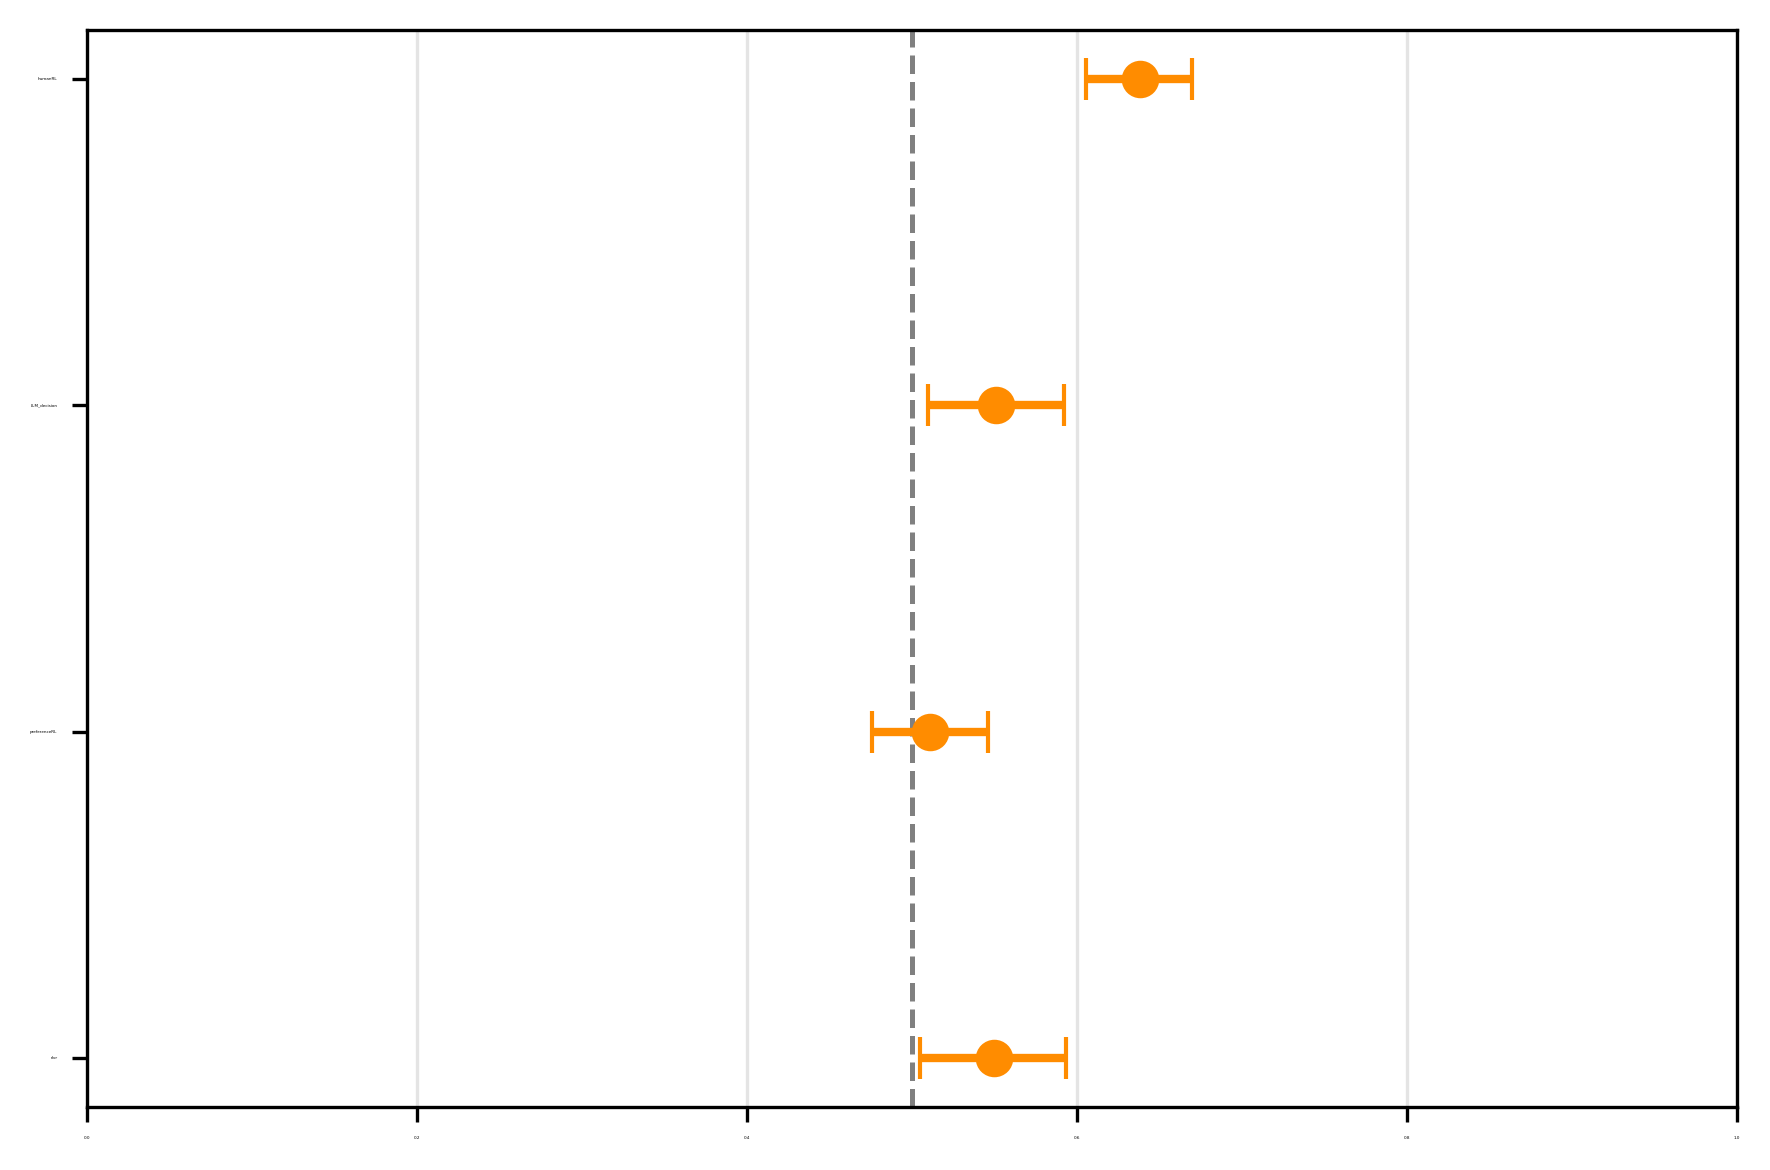

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.lines as mlines

# Data from previous GLMM output
data = {
    'Condition': ['humanRL', 'LLM_decision', 'preferenceRL', 'rlvr'],
    'Raw Accuracy': [0.655949, 0.552799, 0.518694, 0.534321],
    'Model Accuracy': [0.638417, 0.551236, 0.511200, 0.549676],
    'CI Low': [0.605579, 0.509651, 0.475904, 0.504889],
    'CI High': [0.670010, 0.592118, 0.546385, 0.593671]
}
df = pd.DataFrame(data)

# Reverse the dataframe to match the top-to-bottom layout in the target image
df = df.iloc[::-1].reset_index(drop=True)

# Calculate asymmetric errors for xerr in horizontal plot
lower_errors = df['Model Accuracy'] - df['CI Low']
upper_errors = df['CI High'] - df['Model Accuracy']
asymmetric_error = [lower_errors, upper_errors]

# Set up the plot (wide aspect ratio like the image)
fig, ax = plt.subplots(figsize=(6, 4), dpi=300)

# 1. Add vertical grid lines
ax.grid(axis='x', color='lightgray', linestyle='-', alpha=0.6, zorder=0)

# 2. Add chance line (50%)
ax.axvline(x=0.5, color='gray', linestyle='--', linewidth=1.2, zorder=1)

# 3. Plot Model Accuracy with Error Bars (Orange)
# We plot this first so the black crosses sit on top if they overlap
error_bar_plot = ax.errorbar(
    df['Model Accuracy'], 
    df['Condition'], 
    xerr=asymmetric_error,
    fmt='o', 
    color='darkorange', 
    ecolor='darkorange', 
    elinewidth=2, 
    capsize=5, 
    markersize=8, 
    zorder=2
)

# 4. Plot Raw Accuracy (Black crosses)
# ax.scatter(
#     df['Raw Accuracy'], 
#     df['Condition'], 
#     marker='x', 
#     color='black', 
#     s=45, # markersize
#     linewidths=1.5,
#     zorder=3
# )

# Formatting limits and labels
ax.set_xlim(0, 1.0)
ax.set_xlabel('', fontsize=0)
ax.set_title('', fontsize=0, pad=10)

# Customizing the tick parameters
ax.tick_params(axis='y', labelsize=0)
ax.tick_params(axis='x', labelsize=0)

# Recreate the exact legend layout
legend_elements = [
    # mlines.Line2D([0], [0], marker='x', color='w', markeredgecolor='black', markersize=7, markeredgewidth=1.5, label='Raw accuracy'),
    mlines.Line2D([0], [0], color='gray', linestyle='--', linewidth=1.2, label='Chance (50%)'),
    # Use a custom handler for the errorbar in the legend to match the image style
    ax.errorbar([], [], xerr=[[],[]], fmt='o', color='darkorange', ecolor='darkorange', elinewidth=2, capsize=4, markersize=8, label='Model-estimated accuracy (95% CI)')
]

# ax.legend(handles=legend_elements, loc='lower right', fontsize=11, framealpha=1.0, edgecolor='lightgray')

plt.tight_layout()

# Save the plot
plt.savefig('glmm_horizontal_dotplot.svg', bbox_inches='tight')
print("Plot saved as glmm_horizontal_dotplot.png")

/tmp/ipykernel_1062632/716017010.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


Plot saved as ai_text_accuracy_barplot.png


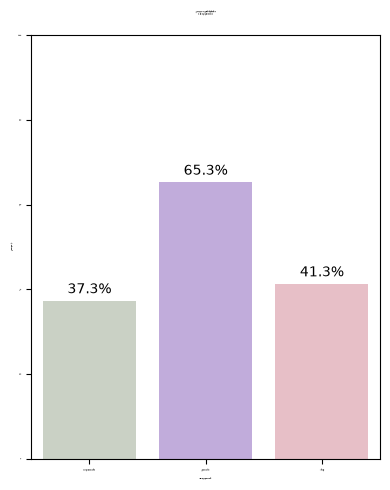

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Data
data = {
    'Explanation Type': ['Human-Focused', 'AI-Focused', 'Neutral'],
    'Accuracy (%)': [37.3, 65.3, 41.3]
}
df = pd.DataFrame(data)

# Set up the plot
plt.figure(figsize=(4, 5))
ax = sns.barplot(
    x='Explanation Type', 
    y='Accuracy (%)', 
    data=df, 
    palette=['#cad3c3', '#c0a4e3', '#eeb8c3'] # Added a third color (green) for Neutral
)

# Add values on the bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3, fontsize=10)

# Formatting 
plt.title('Accuracy on AI-Generated Text\nby Explanation Focus', fontsize=0, pad=15)
plt.xlabel('Explanation Type', fontsize=0) 
plt.ylabel('Accuracy (%)', fontsize=0)
plt.xticks(fontsize=0)
plt.yticks(fontsize=0)
plt.ylim(0, 100) # Scale Y-axis to 100 for percentages

plt.tight_layout()

# Save the plot
plt.savefig('ai_text_accuracy_barplot.svg')
print("Plot saved as ai_text_accuracy_barplot.png")

Plot saved as llm_preference_barplot.png


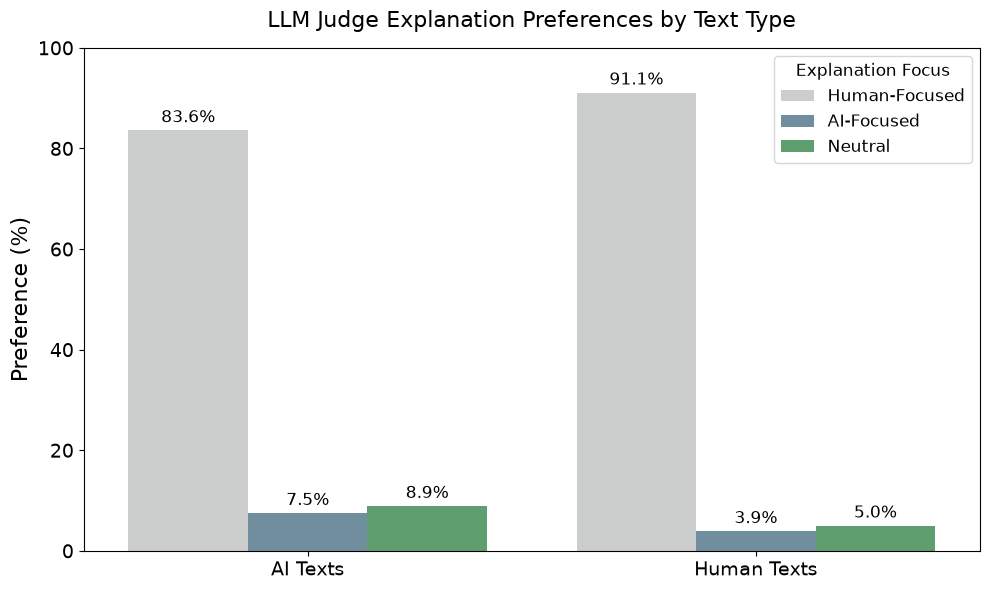

In [11]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Data (Inferring 5.0% Neutral for Human texts to complete the 100% distribution)
data = {
    'Text Type': ['AI Texts', 'AI Texts', 'AI Texts', 'Human Texts', 'Human Texts', 'Human Texts'],
    'Explanation Focus': ['Human-Focused', 'AI-Focused', 'Neutral', 'Human-Focused', 'AI-Focused', 'Neutral'],
    'Preference (%)': [83.6, 7.5, 8.9, 91.1, 3.9, 5.0]
}
df = pd.DataFrame(data)

# Set up the plot
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    x='Text Type', 
    y='Preference (%)', 
    hue='Explanation Focus', 
    data=df, 
    palette=['#cccecd', '#6890a5', '#55a868'] # Blue, Red, Green
)

# Add values on the bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3, fontsize=12)

# Formatting 
plt.title('LLM Judge Explanation Preferences by Text Type', fontsize=16, pad=15)
plt.xlabel('', fontsize=16) 
plt.ylabel('Preference (%)', fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.ylim(0, 100) # Scale Y-axis to 100 for percentages

# Legend formatting
plt.legend(title='Explanation Focus', fontsize=12, title_fontsize=12, loc='upper right')

plt.tight_layout()

# Save the plot
plt.savefig('llm_preference_barplot.png')
print("Plot saved as llm_preference_barplot.png")

Plot saved as vertical_explanation_focus_barplot.png


/tmp/ipykernel_441710/2045589022.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


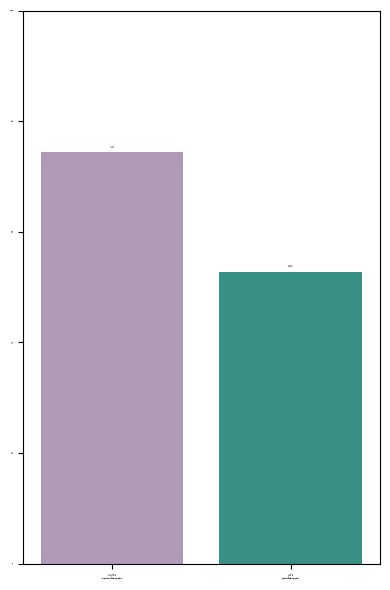

In [14]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Data
data = {
    'Text Category': ['Human Texts\n(Human-Focused Explanations)', 'AI Texts\n(AI-Focused Explanations)'],
    'Percentage (%)': [74.4, 52.8]
}
df = pd.DataFrame(data)

# Set up the plot
plt.figure(figsize=(4, 6))
ax = sns.barplot(
    x='Text Category', 
    y='Percentage (%)', 
    data=df, 
    palette=['#b395bd', '#299d8f']
)

# Add values on the bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3, fontsize=0)

# Formatting 
plt.title('', fontsize=16, pad=15)
plt.xlabel('', fontsize=16) # Left blank since categories are self-explanatory
plt.ylabel('', fontsize=16)
plt.xticks(fontsize=0)
plt.yticks(fontsize=0)
plt.ylim(0, 100) # Since it's percentages, scale the Y-axis to 100

plt.tight_layout()

# Save the plot
plt.savefig('vertical_explanation_focus_barplot.svg')
print("Plot saved as vertical_explanation_focus_barplot.png")

Plot saved as grouped_accuracy_barplot.png


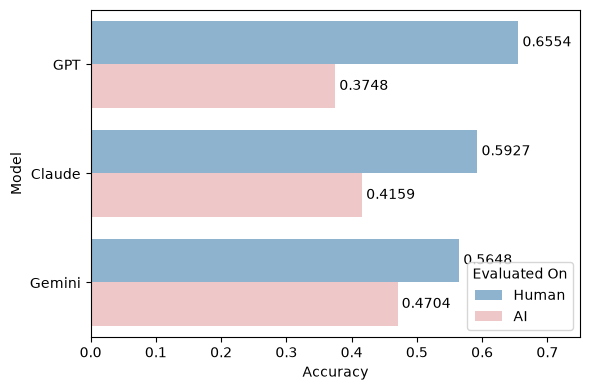

In [19]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Restructure the data to accommodate the grouped (hue) layout
data = {
    'Model': ['GPT', 'Claude', 'Gemini', 'Gemini', 'Claude', 'GPT'],
    'Evaluated On': ['Human', 'Human', 'Human', 'AI', 'AI', 'AI'],
    'Accuracy': [0.655416, 0.592650, 0.564795, 0.470352, 0.415934, 0.374783]
}
df = pd.DataFrame(data)

# Set up the plot
plt.figure(figsize=(6, 4))
ax = sns.barplot(
    x='Accuracy', 
    y='Model', 
    hue='Evaluated On', 
    data=df, 
    order=['GPT', 'Claude', 'Gemini'],
    palette=['#83b4d9', '#f4c2c2'] # Blue for Human, Red for AI dceaf6
)

# Add values on the bars
# 1. Change the font size of the values next to the bars
for container in ax.containers:
    # Set fontsize here (e.g., fontsize=14)
    ax.bar_label(container, fmt='%.4f', padding=3, fontsize=10)

# Formatting
plt.title('', fontsize=0, pad=15)
plt.xlabel('Accuracy', fontsize=10)
plt.ylabel('Model', fontsize=10)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.xlim(0, 0.75) # Set limit slightly higher to make room for labels
plt.legend(title='Evaluated On', loc='lower right')
# ax.get_legend().remove()
plt.tight_layout()

# Save the plot
plt.savefig('grouped_accuracy_barplot.svg')
print("Plot saved as grouped_accuracy_barplot.png")